## Install Dependencies

In [0]:
%pip install -U diffusers transformers accelerate mlflow[databricks]

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

## Download Model from HuggingFace

In [0]:
from huggingface_hub import snapshot_download
import os
import torch
import torchvision

model_path = "Qwen/Qwen-Image-Edit-2509"
model_cache_path = f"/local_disk0/models_cache/{model_path}"
download_models = False

if download_models:
    os.environ["HF_HOME"] = "/local_disk0/hf"
    # os.environ["HF_TOKEN"] = dbutils.secrets.get(
    #     scope="shj_scope", key="hf_secret"
    # )
    
    snapshot_location = snapshot_download(
        repo_id=model_path,
        local_dir=model_cache_path,
        ignore_patterns="*.pth"
    )
else:
    snapshot_location = model_cache_path

snapshot_location

'/local_disk0/models_cache/Qwen/Qwen-Image-Edit-2509'

## Create Inference Config

In [0]:
import yaml

inference_config = {
    "model_type": "qwen_image_edit",
    "use_quantization": False
}

with open('inference_config.yml', 'w') as f:
    yaml.dump(inference_config, f)

## Prepare Input Examples and Signature

In [0]:
from mlflow.models.signature import infer_signature
from PIL import Image
import io
import base64
import pandas as pd

def pillow_image_to_base64_string(img):
    buffered = io.BytesIO()
    img.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

# Load example images
image1 = Image.open("sample_images/01_ice-castle-image.png").convert("RGB")
image2 = Image.open("sample_images/02_brown-bear-image.png").convert("RGB")

# Convert to base64
image1_base64 = pillow_image_to_base64_string(image1)
image2_base64 = pillow_image_to_base64_string(image2)

# Create input example
input_example = pd.DataFrame().from_records([{
    "image1": image1_base64,
    "image2": image2_base64,
    "prompt": "The magician emperor bear is standing in front of castle with a diamond topped septar in his hand. Keep a snowing background and a blue sky."
}])

# Define parameters
params = {
    "num_inference_steps": 40,
    "true_cfg_scale": 4.0,
    "guidance_scale": 1.0,
    "negative_prompt": " ",
    "num_images_per_prompt": 1,
    "seed": 0
}

# Create output example
output_example = pd.DataFrame().from_records([{
    "output_image": "this is an example base64 output image"
}])

signature = infer_signature(input_example, output_example, params)
print(signature)

/databricks/python/lib/python3.12/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


inputs: 
  ['image1': string (required), 'image2': string (required), 'prompt': string (required)]
outputs: 
  ['output_image': string (required)]
params: 
  ['num_inference_steps': long (default: 40), 'true_cfg_scale': double (default: 4.0), 'guidance_scale': double (default: 1.0), 'negative_prompt': string (default:  ), 'num_images_per_prompt': long (default: 1), 'seed': long (default: 0)]



## Log Model to MLflow

In [0]:
import mlflow
from pkg_resources import get_distribution

ds_model_path = os.path.join(os.getcwd(), "imagen_model.py")
config_path = os.path.join(os.getcwd(), "inference_config.yml")

with mlflow.start_run():
    model_info = mlflow.pyfunc.log_model(
        name="model",
        python_model=ds_model_path,
        model_config=config_path,
        artifacts={"model_path": model_cache_path},
        # input_example=input_example,
        signature=signature,
        pip_requirements=[
            f"torch=={get_distribution('torch').version}",
            f"torchvision=={get_distribution('torchvision').version}",
            "diffusers",
            "transformers",
            "accelerate",
            f"mlflow[databricks]=={get_distribution('mlflow').version}"
        ]
    )


model_info.model_uri

🔗 View Logged Model at: https://adb-984752964297111.11.azuredatabricks.net/ml/experiments/5baa46d003494ecba8f5a8e7b9e9df88/models/m-2cc16d6d77164af6a46bc35ca06115ce?o=984752964297111
/local_disk0/.ephemeral_nfs/envs/pythonEnv-a6953659-ca63-4d21-b466-72bd530ffab4/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-a6953659-ca63-4d21-b466-72bd530ffab4/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3285: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about t

'models:/m-2cc16d6d77164af6a46bc35ca06115ce'

## Test the Logged Model

In [0]:
%sh
nvidia-smi

Thu Dec 25 16:32:50 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.07             Driver Version: 535.161.07   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          Off | 00000001:00:00.0 Off |                    0 |
| N/A   27C    P0              42W / 300W |      5MiB / 81920MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [0]:
import mlflow
import pandas as pd
from PIL import Image
import io
import base64

def pillow_image_to_base64_string(img):
    buffered = io.BytesIO()
    img.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

def base64_string_to_pillow_image(base64_str):
    return Image.open(io.BytesIO(base64.decodebytes(bytes(base64_str, "utf-8"))))

# Load example images
image1 = Image.open("sample_images/01_ice-castle-image.png").convert("RGB")
image2 = Image.open("sample_images/02_brown-bear-image.png").convert("RGB")

# Convert to base64
image1_base64 = pillow_image_to_base64_string(image1)
image2_base64 = pillow_image_to_base64_string(image2)

# Create input
input_example = pd.DataFrame().from_records([{
    "image1": image1_base64,
    "image2": image2_base64,
    "prompt": "The magician emperor bear is standing in front of castle with a diamond topped septar in his hand. Keep a snowing background and a blue sky. Do not include any bookmarks"
}])

/databricks/python/lib/python3.12/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [0]:
# Load the model (replace with your actual model URI from above)
model_uri = model_info.model_uri #'models:/m-7451867a46dc441e9beec6889e1193af'
loaded_model = mlflow.pyfunc.load_model(model_uri)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a6953659-ca63-4d21-b466-72bd530ffab4/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
total devices found in system: 1 and device: cuda


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Qwen Image Edit pipeline loaded successfully


guidance_scale is passed as 1.0, but ignored since the model is not guidance-distilled.


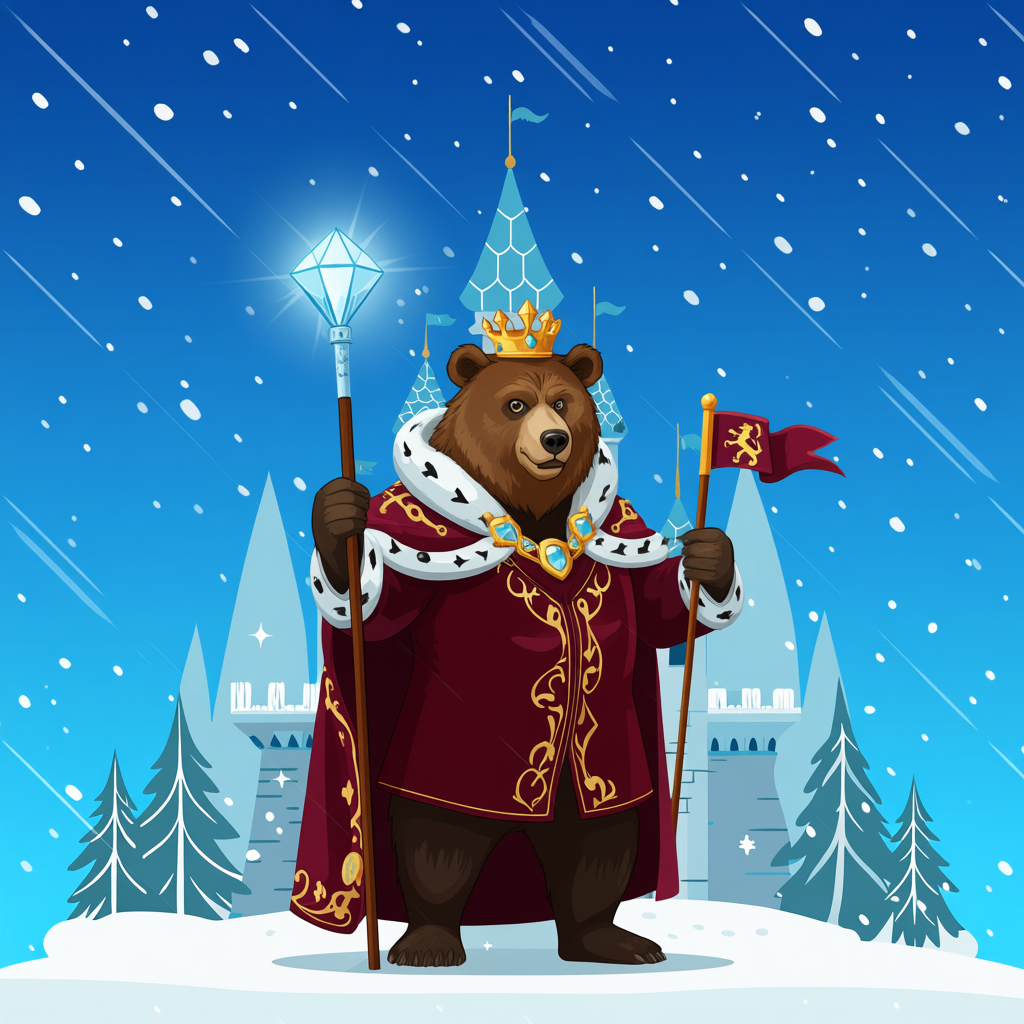

In [0]:
# Predict
output = loaded_model.predict(
    input_example,
    params={
        "num_inference_steps": 40,
        "true_cfg_scale": 4.0,
        "guidance_scale": 1.0,
        "negative_prompt": " ",
        "num_images_per_prompt": 1,
        "seed": 0
    }
)

# Display the output image
output_image_base64 = output.iloc[0]["output_image"]
output_image = base64_string_to_pillow_image(output_image_base64)
display(output_image)

In [0]:
# Save the output image
# output_image.save("sample_images/output_image_mlflow_test.png")
# print("Image saved at sample_images/output_image_mlflow_test.png")

## Register Model to Unity Catalog

In [0]:
mlflow.set_registry_uri("databricks-uc")
registered_model = mlflow.register_model(
    model_uri,
    "uc_sriharsha_jana.default.qwen_image_edit_model"
)

Registered model 'uc_sriharsha_jana.default.qwen_image_edit_model' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/116 [00:00<?, ?it/s]

Uploading /local_disk0/repl_tmp_data/ReplId-19b56-099e6-2/tmp6qz_zy7w/artifacts/Qwen-Image-Edit-2509/transform…

Uploading /local_disk0/repl_tmp_data/ReplId-19b56-099e6-2/tmp6qz_zy7w/artifacts/Qwen-Image-Edit-2509/transform…

Uploading /local_disk0/repl_tmp_data/ReplId-19b56-099e6-2/tmp6qz_zy7w/artifacts/Qwen-Image-Edit-2509/transform…

...

Uploading /local_disk0/repl_tmp_data/ReplId-19b56-099e6-2/tmp6qz_zy7w/artifacts/Qwen-Image-Edit-2509/text_enco…

Uploading /local_disk0/repl_tmp_data/ReplId-19b56-099e6-2/tmp6qz_zy7w/artifacts/Qwen-Image-Edit-2509/text_enco…

Uploading /local_disk0/repl_tmp_data/ReplId-19b56-099e6-2/tmp6qz_zy7w/artifacts/Qwen-Image-Edit-2509/text_enco…

Uploading /local_disk0/repl_tmp_data/ReplId-19b56-099e6-2/tmp6qz_zy7w/artifacts/Qwen-Image-Edit-2509/text_enco…

🔗 Created version '2' of model 'uc_sriharsha_jana.default.qwen_image_edit_model': https://adb-984752964297111.11.azuredatabricks.net/explore/data/models/uc_sriharsha_jana/default/qwen_image_edit_model/version/2?o=984752964297111


In [0]:
from mlflow import MlflowClient

mlflow_client = MlflowClient()
mlflow_client.set_registered_model_alias("uc_sriharsha_jana.default.qwen_image_edit_model", "staging", registered_model.version)